You are given an m x n grid. Each cell of grid represents a street. The street of grid[i][j] can be:

    1 which means a street connecting the left cell and the right cell.
    2 which means a street connecting the upper cell and the lower cell.
    3 which means a street connecting the left cell and the lower cell.
    4 which means a street connecting the right cell and the lower cell.
    5 which means a street connecting the left cell and the upper cell.
    6 which means a street connecting the right cell and the upper cell.

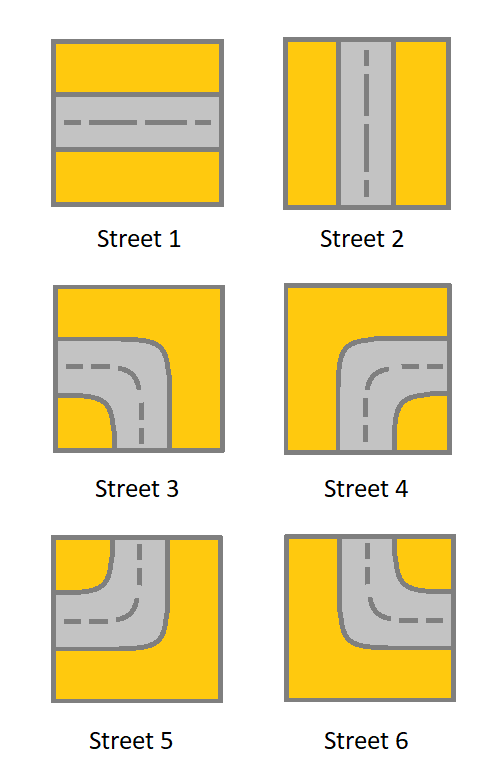

You will initially start at the street of the upper-left cell (0, 0). A valid path in the grid is a path that starts from the upper left cell (0, 0) and ends at the bottom-right cell (m - 1, n - 1). The path should only follow the streets.

Notice that you are not allowed to change any street.

Return true if there is a valid path in the grid or false otherwise.

 

Example 1:

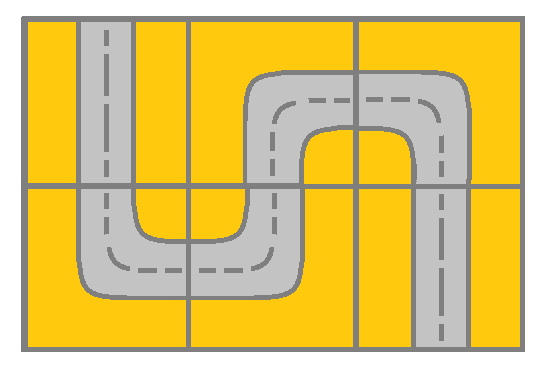

Input: grid = [[2,4,3],[6,5,2]]
Output: true
Explanation: As shown you can start at cell (0, 0) and visit all the cells of the grid to reach (m - 1, n - 1).

Example 2:

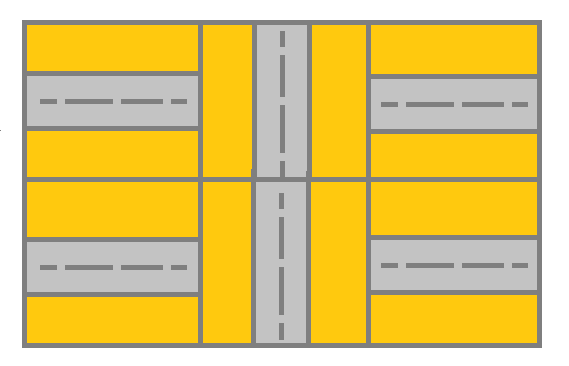

Input: grid = [[1,2,1],[1,2,1]]
Output: false
Explanation: As shown you the street at cell (0, 0) is not connected with any street of any other cell and you will get stuck at cell (0, 0)

Example 3:

Input: grid = [[1,1,2]]
Output: false
Explanation: You will get stuck at cell (0, 1) and you cannot reach cell (0, 2).

 

Constraints:

    m == grid.length
    n == grid[i].length
    1 <= m, n <= 300
    1 <= grid[i][j] <= 6

 

In [ ]:
class Solution:
    class DisjointSet:
        def __init__(self, n):
            self.f = list(range(n))

        def find(self, x):
            if x == self.f[x]:
                return x
            self.f[x] = self.find(self.f[x])
            return self.f[x]

        def merge(self, x, y):
            self.f[self.find(x)] = self.find(y)
    
    def hasValidPath(self, grid: List[List[int]]) -> bool:
        m, n = len(grid), len(grid[0])
        patterns = [0, 0b1010, 0b0101, 0b1100, 0b0110, 0b1001, 0b0011]
        dirs = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        ds = Solution.DisjointSet(m * n)

        def getId(x, y):
            return x * n + y

        def handler(x, y):
            pattern = patterns[grid[x][y]]
            for i, (dx, dy) in enumerate(dirs):
                if (pattern & (1 << i)) > 0:
                    sx, sy = x + dx, y + dy
                    if (
                        0 <= sx < m
                        and 0 <= sy < n
                        and (patterns[grid[sx][sy]] & (1 << ((i + 2) % 4))) > 0
                    ):
                        ds.merge(getId(x, y), getId(sx, sy))

        for i in range(m):
            for j in range(n):
                handler(i, j)

        return ds.find(getId(0, 0)) == ds.find(getId(m - 1, n - 1))